# 한국 관광 출입국통계 수집 v2 → investar 적재

한국관광공사 **출입국관광통계** API에서 월별 국적별 입국자수를 수집해 investar에 저장합니다.

**저장 테이블 (investar, 표준 규격 STD-1)**

| 테이블 / 뷰 | 내용 | 키 |
|---|---|---|
| `kr_tourism_country_info` | 국적 코드표 (국가코드, 국적명, 최근 사용 이름) | nat_code |
| `kr_tourism_visitors_monthly` | 월별 국적별 관광객 수 | direction, nat_code, period_end |
| `kr_tourism_visitors_monthly_vintage` | 값이 처음 들어오거나 바뀐 이력 | id |
| `v_kr_tourism_visitors_total` (뷰) | 월별 전체 합계 (소계 제외 국적 반영) | direction, period_end |

- `direction`: `E` = 방한 외래관광객(입국), `D` = 국민 해외관광객(출국)
- STD-1: 소문자 snake_case / utf8mb4_general_ci / `period_end`(월말) + `freq` / 수집 시각 KST / 이력은 `_vintage`

**v2 변경점**
- investar 적재 추가. DB에 이미 있으면 **최근 몇 개월만** 받아 갱신 (처음엔 전체 기간)
- 서비스키를 코드에서 빼고 `DATA.KEYS`에서 읽음
- 응답 건수(totalCount)가 한 페이지를 넘으면 자동으로 다음 페이지까지 받음
- 차트/순위는 DB 전체 이력으로 그림 (증분 수집이어도 전체 기간 차트 유지)
- CSV 저장은 기본 꺼짐 (`SAVE_CSV = True`로 켜기)

## 1. 설정
`ED_CODE`: `E` 방한 외래관광객(입국, 기본) / `D` 국민 해외관광객(출국)

In [1]:
# -*- coding: utf-8 -*-
import os
import sys
from pathlib import Path

# ============================================================
# 사용자 설정
# ============================================================
# 서비스키: 코드에 직접 쓰지 않고 DATA/KEYS.py 에서 읽습니다.
#   KEYS["TOUR"] 가 있으면 사용, 없으면 KEYS["ODPD"](공공데이터포털 키), 그것도 없으면 환경변수 TOUR_SERVICE_KEY
#   (공공데이터포털 Decoding 키)
SERVICE_KEY_NAMES = ("TOUR", "ODPD")

# 수집 방향  E=방한외래관광객(입국) / D=국민해외관광객(출국)
ED_CODE = "E"

# 수집 기간
MODE = "auto"             # "auto": DB에 있으면 최근 REFRESH_MONTHS개월만, 없으면 YEARS_BACK년 전체 / "full": 항상 전체
YEARS_BACK = 15           # 전체 수집 시 최근 N년
REFRESH_MONTHS = 3        # auto 모드에서 DB 마지막 월 기준으로 다시 받을 개월 수 (수정치 반영)
BEGIN_YM = None           # 직접 지정하려면 "201001" 형태 (지정하면 MODE 무시)
END_YM   = None           # None 이면 지난달까지

# 와이드 표의 앞쪽 컬럼 순서
FOCUS_COUNTRIES = ["중국", "일본", "대만", "미국", "홍콩"]
TOP_N_CHART = 5           # 차트 상위 N개국 (최근 12개월 누적 기준 자동 선정)
SMOOTH_MONTHS = 12        # 이동평균 개월 수

# 동시 요청 수. 관광공사 API 는 과하면 실패가 늘어나므로 5 정도가 무난
MAX_WORKERS = 5
RETRIES = 2
TIMEOUT = 20

# ------------------------------------------------------------
# 저장 설정
# ------------------------------------------------------------
SAVE_DB = True            # investar 적재

# CSV 저장: 당분간 사용 안 함 → 기본 False
#   켜려면 SAVE_CSV = True. 저장 경로는 아래 OneDrive 설정으로 자동 탐색되며,
#   직접 지정하려면 OUT_DIR_OVERRIDE = r"C:\...\tourism" 처럼 입력 (앞의 r 필수)
SAVE_CSV = False
OUT_DIR_OVERRIDE = None
ONEDRIVE_SUBPATH = ("INVESTMENT", "지표상회_복제", "tourism")
ANCHOR_FOLDER = "지표상회_복제"
LEAF_FOLDER   = "tourism"
FILE_PREFIX = "korea_visiting_num"
DATE_TAG_MODE = "lastdata"   # "lastdata" = 데이터 최종 월(YYYYMM), "today" = 실행일(YYYYMMDD)
OVERWRITE = True
SAVE_LONG = True             # SAVE_CSV 일 때 전 국적 long CSV 도 저장

# ============================================================
BASE_URL = ("http://openapi.tour.go.kr/openapi/service/"
            "EdrcntTourismStatsService/getEdrcntTourismStatsList")

print(sys.version.split()[0], "| 방향:", "방한 외래객(E)" if ED_CODE == "E" else "국민 해외여행(D)")

3.9.10 | 방향: 방한 외래객(E)


## 2. 접속 준비 (DATA 폴더, 서비스키, DB)

In [2]:
def setup_universal_paths():
    """현재 폴더에서 상위로 올라가며 DATA 폴더를 찾아 sys.path에 추가."""
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "DATA").exists():
            for p in (str(parent), str(parent / "DATA")):
                if p not in sys.path:
                    sys.path.insert(0, p)
            return parent
    return None


ROOT = setup_universal_paths()
print("프로젝트 루트:", ROOT)

try:
    from DATA.KEYS import KEYS
except ImportError:
    KEYS = {}
SERVICE_KEY = next((KEYS.get(k) for k in SERVICE_KEY_NAMES if KEYS.get(k)), None) \
              or os.environ.get("TOUR_SERVICE_KEY")
if not SERVICE_KEY:
    raise RuntimeError("서비스키가 없습니다. DATA/KEYS.py 에 KEYS['TOUR'] = '...' 를 추가하세요.")
print("서비스키 로드 완료 (", next((k for k in SERVICE_KEY_NAMES if KEYS.get(k)), "환경변수"), ")")

engine = None
if SAVE_DB:
    import config
    engine = config.get_engine(config.get_db_info())
    print("DB 엔진 준비 완료")

프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
서비스키 로드 완료 ( ODPD )
DB 엔진 준비 완료


## 3. CSV 저장 경로 탐색 (`SAVE_CSV = True`일 때만)

In [3]:
# -*- coding: utf-8 -*-
import os
import glob


def _dedup(seq):
    seen, out = set(), []
    for x in seq:
        if x and x not in seen:
            seen.add(x)
            out.append(x)
    return out


def find_onedrive_roots():
    roots = []
    for var in ("OneDrive", "OneDriveConsumer", "OneDriveCommercial"):
        roots.append(os.environ.get(var))

    home = os.path.expanduser("~")
    for pat in ("OneDrive", "OneDrive*", "OneDrive - *"):
        for hit in glob.glob(os.path.join(home, pat)):
            if os.path.isdir(hit):
                roots.append(hit)

    for drive in ("C:", "D:", "E:"):
        cand = os.path.join(drive + os.sep, "OneDrive")
        if os.path.isdir(cand):
            roots.append(cand)

    return _dedup([os.path.normpath(r) for r in roots if r and os.path.isdir(r)])


def search_folder_by_name(roots, name, max_depth=5):
    for root in roots:
        base_depth = root.rstrip(os.sep).count(os.sep)
        for dirpath, dirnames, _ in os.walk(root):
            if dirpath.count(os.sep) - base_depth >= max_depth:
                dirnames[:] = []
                continue
            dirnames[:] = [d for d in dirnames
                           if not d.startswith(".") and not d.startswith("~$")]
            if name in dirnames:
                return os.path.join(dirpath, name)
    return None


def resolve_out_dir(verbose=True):
    sub = os.path.join(*ONEDRIVE_SUBPATH)

    if OUT_DIR_OVERRIDE:
        path = os.path.normpath(os.path.expanduser(OUT_DIR_OVERRIDE))
        os.makedirs(path, exist_ok=True)
        if verbose:
            print("[1] OUT_DIR_OVERRIDE 사용")
        return path

    roots = find_onedrive_roots()
    if verbose:
        print("탐지된 OneDrive 루트:")
        for r in roots:
            print("   -", r)
        if not roots:
            print("   (없음)")
        print()

    candidates = [os.path.join(r, sub) for r in roots]

    for c in candidates:
        if os.path.isdir(c):
            if verbose:
                print("[2] 기존 폴더 발견")
            return c

    for c in candidates:
        if os.path.isdir(os.path.dirname(c)):
            os.makedirs(c, exist_ok=True)
            if verbose:
                print("[4] 상위 폴더 확인 후 tourism 생성")
            return c

    if roots:
        if verbose:
            print("[5] '{}' 를 이름으로 검색 중...".format(ANCHOR_FOLDER))
        anchor = search_folder_by_name(roots, ANCHOR_FOLDER)
        if anchor:
            path = os.path.join(anchor, LEAF_FOLDER)
            os.makedirs(path, exist_ok=True)
            if verbose:
                print("[5] 앵커 발견 →", anchor)
            return path

    fallback = os.path.abspath(os.path.join("./data", LEAF_FOLDER))
    os.makedirs(fallback, exist_ok=True)
    if verbose:
        print("[6] !! OneDrive 경로를 찾지 못해 로컬 폴더로 폴백합니다.")
        print("     OUT_DIR_OVERRIDE 에 경로를 직접 넣어주세요.")
    return fallback


OUT_DIR = None
if SAVE_CSV:
    OUT_DIR = resolve_out_dir()
    print()
    print("최종 저장 경로 :", OUT_DIR)
    print("쓰기 가능 여부 :", os.access(OUT_DIR, os.W_OK))
else:
    print("CSV 저장 꺼짐 (SAVE_CSV = False)")

CSV 저장 꺼짐 (SAVE_CSV = False)


## 4. 수집 함수
응답 필드: `ym`(년월), `natCd`(국가코드), `natKorNm`(국적명), `num`(인원), `ed`/`edCd`(구분).
인증 실패나 트래픽 초과는 `<OpenAPI_ServiceResponse>` 봉투로 오므로 두 형태를 모두 처리합니다.

In [4]:
# -*- coding: utf-8 -*-
import time
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from dateutil.relativedelta import relativedelta

import requests
import pandas as pd


OK_CODES = {"0000", "00", "0", ""}


class TourismApiError(Exception):
    pass


def build_month_list(years_back=15, begin_ym=None, end_ym=None):
    """YYYYMM 문자열 리스트 생성. 기본은 최근 N년 ~ 지난달"""
    end = (datetime.strptime(end_ym, "%Y%m") if end_ym
           else datetime.now() - relativedelta(months=1))
    start = (datetime.strptime(begin_ym, "%Y%m") if begin_ym
             else end - relativedelta(years=years_back))

    out, cur = [], start.replace(day=1)
    while cur <= end:
        out.append(cur.strftime("%Y%m"))
        cur += relativedelta(months=1)
    return out


def _parse(text):
    """XML 응답 → item 딕셔너리 리스트"""
    root = ET.fromstring(text)

    # 인증/트래픽 오류 봉투
    if root.tag.endswith("OpenAPI_ServiceResponse"):
        code = root.findtext(".//returnReasonCode") or "?"
        msg = (root.findtext(".//returnAuthMsg")
               or root.findtext(".//errMsg") or "")
        raise TourismApiError("[{}] {}".format(code, msg))

    rc = (root.findtext(".//resultCode") or "").strip()
    if rc not in OK_CODES:
        msg = (root.findtext(".//resultMsg") or "").strip()
        raise TourismApiError("[{}] {}".format(rc, msg))

    rows = []
    for item in root.iter("item"):
        rows.append({ch.tag: (ch.text or "").strip() for ch in item})
    total = (root.findtext(".//totalCount") or "").strip()
    return rows, (int(total) if total.isdigit() else None)


def fetch_month(ym, ed_code=None, nat_cd=None, retries=None, timeout=None):
    """단일 월 조회. nat_cd 를 주지 않으면 그 달의 전 국적이 한 번에 온다."""
    ed_code = ed_code or ED_CODE
    retries = RETRIES if retries is None else retries
    timeout = TIMEOUT if timeout is None else timeout

    params = {"serviceKey": SERVICE_KEY, "YM": ym, "ED_CD": ed_code,
              "numOfRows": 1000, "pageNo": 1}
    if nat_cd:
        params["NAT_CD"] = str(nat_cd)

    def _mask(msg):
        return str(msg).replace(SERVICE_KEY, "***") if SERVICE_KEY else str(msg)

    out, page = [], 1
    while True:
        params["pageNo"] = page
        last, got = None, None
        for attempt in range(retries + 1):
            try:
                r = requests.get(BASE_URL, params=params, timeout=timeout)
                r.raise_for_status()
                got = _parse(r.text)
                break
            except TourismApiError as e:
                return [], _mask(e)        # API 레벨 오류는 재시도해도 동일
            except Exception as e:
                last = e
                if attempt < retries:
                    time.sleep(0.4 * (attempt + 1))
        if got is None:
            return [], _mask("{}: {}".format(type(last).__name__, last))
        rows, total = got
        out.extend(rows)
        # totalCount 가 한 페이지(numOfRows)를 넘으면 다음 페이지
        if not rows or total is None or len(out) >= total or page >= 20:
            break
        page += 1
    return out, None


def fetch_bulk(month_list, ed_code=None, max_workers=None, verbose=True):
    """여러 달을 병렬 수집. 실패한 달 목록도 함께 반환."""
    max_workers = max_workers or MAX_WORKERS
    rows, failed, empty = [], [], []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(fetch_month, ym, ed_code): ym for ym in month_list}
        done = 0
        for fut in as_completed(futs):
            ym = futs[fut]
            try:
                data, err = fut.result()
            except Exception as e:
                data, err = [], str(e)

            if err:
                failed.append((ym, err))
            elif not data:
                empty.append(ym)           # 미발표 등으로 빈 응답
            else:
                rows.extend(data)

            done += 1
            if verbose and done % 24 == 0:
                print("   진행 {:>3}/{:<3}  누적 {:,}행".format(
                    done, len(month_list), len(rows)))

    if verbose:
        print("\n수집 완료: {:,}행 / 실패 {}개월 / 빈 응답 {}개월{}".format(
            len(rows), len(failed), len(empty),
            " ({})".format(", ".join(sorted(empty))) if empty else ""))
        for ym, err in failed[:5]:
            print("   실패 {} → {}".format(ym, err))
        if len(failed) > 5:
            print("   ... 외 {}개월".format(len(failed) - 5))

    return pd.DataFrame(rows), failed


print("수집 함수 로드 완료")

수집 함수 로드 완료


## 5. DB 테이블 생성 (없을 때만)

In [5]:
from sqlalchemy import text

T_COUNTRY = "kr_tourism_country_info"
T_DATA = "kr_tourism_visitors_monthly"
T_VIN = "kr_tourism_visitors_monthly_vintage"
V_TOTAL = "v_kr_tourism_visitors_total"
_OPTS = "ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci"

DDL = [
f"""
CREATE TABLE IF NOT EXISTS {T_COUNTRY} (
    nat_code           VARCHAR(10)  NOT NULL COMMENT '관광공사 국가코드 (natCd)',
    country_name       VARCHAR(100) NOT NULL COMMENT '국적명 (공백 제거)',
    country_name_raw   VARCHAR(100) NULL     COMMENT 'API 원문 국적명',
    exclude_from_total TINYINT      NOT NULL DEFAULT 0 COMMENT '1이면 전체 합계에서 제외 (소계 등)',
    first_collected_at DATETIME     NOT NULL,
    last_collected_at  DATETIME     NOT NULL,
    created_at         TIMESTAMP    NOT NULL DEFAULT CURRENT_TIMESTAMP,
    updated_at         TIMESTAMP    NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    PRIMARY KEY (nat_code),
    KEY idx_name (country_name)
) {_OPTS} COMMENT='출입국관광통계 국적 코드표 (STD-1)'
""",
f"""
CREATE TABLE IF NOT EXISTS {T_DATA} (
    direction          CHAR(1)     NOT NULL COMMENT 'E=방한 외래관광객(입국), D=국민 해외관광객(출국)',
    nat_code           VARCHAR(10) NOT NULL,
    period_end         DATE        NOT NULL COMMENT '월말일',
    freq               CHAR(1)     NOT NULL DEFAULT 'M',
    visitors           BIGINT      NULL     COMMENT '인원',
    unit               VARCHAR(20) NOT NULL DEFAULT 'persons',
    source             VARCHAR(30) NOT NULL DEFAULT 'tour_api_edrcnt',
    first_collected_at DATETIME    NOT NULL COMMENT '최초 관측 시각(KST)',
    last_collected_at  DATETIME    NOT NULL COMMENT '최근 관측 시각(KST)',
    created_at         TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP,
    updated_at         TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    PRIMARY KEY (direction, nat_code, period_end),
    KEY idx_period_end (period_end)
) {_OPTS} COMMENT='출입국관광통계 월별 국적별 관광객 수 (STD-1)'
""",
f"""
CREATE TABLE IF NOT EXISTS {T_VIN} (
    id           BIGINT      NOT NULL AUTO_INCREMENT,
    direction    CHAR(1)     NOT NULL,
    nat_code     VARCHAR(10) NOT NULL,
    period_end   DATE        NOT NULL,
    visitors     BIGINT      NULL,
    change_type  VARCHAR(10) NOT NULL COMMENT 'new | revised',
    collected_at DATETIME    NOT NULL COMMENT '이 값을 관측한 시각(KST)',
    created_at   TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (id),
    KEY idx_key_time (direction, nat_code, period_end, collected_at)
) {_OPTS} COMMENT='출입국관광통계 관측 이력 (STD-1 vintage)'
""",
f"""
CREATE OR REPLACE VIEW {V_TOTAL} AS
SELECT d.direction, d.period_end, SUM(d.visitors) AS visitors, COUNT(*) AS n_countries
FROM {T_DATA} d
JOIN {T_COUNTRY} c ON c.nat_code = d.nat_code
WHERE c.exclude_from_total = 0
GROUP BY d.direction, d.period_end
""",
]

if SAVE_DB:
    with engine.begin() as cx:
        for ddl in DDL:
            cx.execute(text(ddl))
    print("테이블 준비 완료:", T_COUNTRY, T_DATA, T_VIN, "+ 뷰", V_TOTAL)
else:
    print("DB 저장 꺼짐 (SAVE_DB = False)")

테이블 준비 완료: kr_tourism_country_info kr_tourism_visitors_monthly kr_tourism_visitors_monthly_vintage + 뷰 v_kr_tourism_visitors_total


## 6. DB 적재 함수

In [6]:
from datetime import timezone, timedelta

KST = timezone(timedelta(hours=9))


def now_kst():
    return datetime.now(KST).replace(tzinfo=None, microsecond=0)


def db_last_period(direction):
    with engine.connect() as cx:
        return cx.execute(text(f"SELECT MAX(period_end) FROM {T_DATA} WHERE direction = :d"),
                          {"d": direction}).scalar()


def save_to_db(tidy, direction, exclude_names=()):
    """tidy: 컬럼 [날짜, 국가코드, 국적, 국적_원문, 인원]. 반환: (저장 건수, 신규, 수정)"""
    ts = now_kst()
    t = tidy.dropna(subset=["인원"]).copy()
    t["period_end"] = pd.to_datetime(t["날짜"]).dt.date

    # 국적 코드표: 가장 최근 월의 이름을 대표 이름으로
    latest = t.sort_values("period_end").drop_duplicates("국가코드", keep="last")
    country = [{"nat_code": r.국가코드, "country_name": r.국적, "country_name_raw": r.국적_원문,
                "excl": int(r.국적 in exclude_names), "ts": ts} for r in latest.itertuples()]
    data = [{"direction": direction, "nat_code": r.국가코드, "period_end": r.period_end,
             "visitors": int(r.인원), "ts": ts} for r in t.itertuples()]

    sql_country = f"""
    INSERT INTO {T_COUNTRY} (nat_code, country_name, country_name_raw, exclude_from_total,
                             first_collected_at, last_collected_at)
    VALUES (:nat_code, :country_name, :country_name_raw, :excl, :ts, :ts)
    ON DUPLICATE KEY UPDATE
        country_name = VALUES(country_name), country_name_raw = VALUES(country_name_raw),
        exclude_from_total = VALUES(exclude_from_total), last_collected_at = VALUES(last_collected_at)
    """
    sql_data = f"""
    INSERT INTO {T_DATA} (direction, nat_code, period_end, freq, visitors, first_collected_at, last_collected_at)
    VALUES (:direction, :nat_code, :period_end, 'M', :visitors, :ts, :ts)
    ON DUPLICATE KEY UPDATE
        visitors = VALUES(visitors),
        first_collected_at = LEAST(first_collected_at, VALUES(first_collected_at)),
        last_collected_at  = GREATEST(last_collected_at, VALUES(last_collected_at))
    """
    sql_vin = f"""
    INSERT INTO {T_VIN} (direction, nat_code, period_end, visitors, change_type, collected_at)
    VALUES (:direction, :nat_code, :period_end, :visitors, :change_type, :ts)
    """
    with engine.begin() as cx:
        pmin, pmax = t["period_end"].min(), t["period_end"].max()
        existing = {(c, p): v for c, p, v in cx.execute(
            text(f"SELECT nat_code, period_end, visitors FROM {T_DATA} "
                 f"WHERE direction = :d AND period_end BETWEEN :a AND :b"),
            {"d": direction, "a": pmin, "b": pmax})}
        vin = []
        for r in data:
            key = (r["nat_code"], r["period_end"])
            if key not in existing:
                vin.append(dict(r, change_type="new"))
            elif existing[key] != r["visitors"]:
                vin.append(dict(r, change_type="revised"))
        cx.execute(text(sql_country), country)
        for i in range(0, len(data), 2000):
            cx.execute(text(sql_data), data[i:i + 2000])
        if vin:
            cx.execute(text(sql_vin), vin)
    n_new = sum(1 for v in vin if v["change_type"] == "new")
    return len(data), n_new, len(vin) - n_new


def load_from_db(direction):
    """DB 전체 이력 → long DataFrame [날짜, 국가코드, 국적, 인원, 제외]"""
    q = text(f"""SELECT d.period_end AS 날짜, d.nat_code AS 국가코드, c.country_name AS 국적,
                        d.visitors AS 인원, c.exclude_from_total AS 제외
                 FROM {T_DATA} d JOIN {T_COUNTRY} c ON c.nat_code = d.nat_code
                 WHERE d.direction = :d ORDER BY d.period_end, c.country_name""")
    with engine.connect() as cx:
        out = pd.read_sql(q, cx, params={"d": direction})
    out["날짜"] = pd.to_datetime(out["날짜"])
    return out

print("DB 함수 준비 완료")

DB 함수 준비 완료


## 7. 연결 테스트 (한 달치)

In [7]:
_all_months = build_month_list(YEARS_BACK, BEGIN_YM, END_YM)
test_ym = _all_months[-1]
rows, err = fetch_month(test_ym)
if not err and not rows:
    # 지난달이 아직 미발표면 그 전 달로 테스트
    test_ym = _all_months[-2]
    rows, err = fetch_month(test_ym)
if err:
    print("\n!! 실패:", err)
else:
    print("\n{} : {}개 국적".format(test_ym, len(rows)))
    print("\n필드 구조:")
    for k, v in (rows[0] if rows else {}).items():
        print("   {:<12} {}".format(k, v))
    print("\n상위 5개:")
    for r in sorted(rows, key=lambda x: -int(x.get("num", 0) or 0))[:5]:
        print("   {:<16} {:>12,}".format(r.get("natKorNm", ""),
                                         int(r.get("num", 0) or 0)))


202608 : 200개 국적

필드 구조:
   ed           방한외래관광객
   edCd         E
   natCd        105
   natKorNm     방글라데시
   num          4223
   rnum         1
   ym           202608

상위 5개:
   중  국                  827,704
   일  본                  418,698
   대  만                  245,277
   미  국                  117,304
   홍  콩                   78,792


## 5. 국적 목록 진단 (중요)

전 국적을 합산해 '전체'를 만들 때, 응답에 **대륙 소계나 합계 행이 섞여 있으면
이중 계산**이 됩니다. 기존 코드는 이 확인 없이 그냥 `sum()` 을 했습니다.

아래에서 국적명을 전부 출력하고, 소계로 의심되는 항목을 표시합니다.
의심 항목이 있으면 `EXCLUDE_NAMES` 에 넣으세요.

In [8]:
SUSPECT = ("합계", "소계", "총계", "전체", "기타", "대륙", "아시아주", "구주", "미주", "아주", "대양주")

if not err and rows:
    names = sorted({r.get("natKorNm", "") for r in rows})
    print("국적 수:", len(names))
    print()
    flagged = [n for n in names if any(s in n for s in SUSPECT)]
    for n in names:
        mark = "  ← 확인 필요" if n in flagged else ""
        print("   {}{}".format(n, mark))
    print()
    if flagged:
        print("!! 소계 의심 항목 {}개: {}".format(len(flagged), flagged))
        print("   실제 소계라면 아래 EXCLUDE_NAMES 에 넣으세요.")
    else:
        print("소계로 보이는 항목 없음 → 단순 합산해도 안전합니다.")

# 합산에서 제외할 국적명 (공백 제거된 이름 기준. 위 진단 결과를 보고 채우세요)
# 여기 넣은 국적은 DB에는 그대로 저장되고, 코드표의 exclude_from_total = 1 로 표시되어
# 전체 합계(뷰 v_kr_tourism_visitors_total, 차트의 '전체')에서만 빠집니다.
EXCLUDE_NAMES = []

국적 수: 200

   가  나
   가  봉
   가이아나
   감비아
   과테말라
   교포
   국제연합
   그레나다
   그루지아
   그리스
   기  니
   기니비사우
   나미비아
   나우루
   나이지리아
   남수단공화국
   남아프리카 공화국
   네  팔
   네덜란드
   노르웨이
   뉴질랜드
   니제르
   니카라과
   대  만
   덴마크
   도미니카공화국
   도미니카연방
   독  일
   라오스
   라이베리아
   라트비아
   러시아(연방)
   레바논
   레소토
   루마니아
   룩셈부르크
   르완다
   리비아
   리투아니아
   리히텐슈타인
   마다가스카르
   마샬군도
   마카오
   마케도니아
   말  리
   말라위
   말레이시아
   멕시코
   모나코
   모로코
   모리셔스
   모리타니
   모잠비크
   몬테네그로
   몰  타
   몰도바
   몰디브
   몽  골
   미  국
   미상
   미얀마
   미크로네시아
   바레인
   바베이도스
   바하마
   방글라데시
   베  냉
   베네수엘라
   베트남
   벨기에
   벨로루시
   벨리즈
   보스니아-헤르체고비나
   보츠와나
   볼리비아
   부  탄
   부룬디
   부르키나파소
   불가리아
   브라질
   브루나이
   비누아투
   사모아
   사우디아라비아
   산마리노
   세네갈
   세르비아
   세이셸
   세인트루시아
   세인트빈센트 그레나딘
   세인트크리스토퍼 네비스
   소말리아
   솔로몬군도
   수  단
   수리남
   스리랑카
   스와질란드
   스웨덴
   스위스
   스페인
   슬로바크
   슬로베니아
   시리아
   시에라리온
   싱가포르
   아랍에미리트연합
   아르메니아
   아르헨티나
   아이슬란드
   아이티
   아일랜드
   아제르바이잔
   아프가니스탄
   안도라
   알바니아
   알제리
   앙골라
   앤티가 바부다
   에리트레

## 8. 수집 기간 결정 및 수집
- `MODE = "auto"`: DB 마지막 월 기준 최근 `REFRESH_MONTHS`개월 ~ 지난달 (DB가 비어 있으면 전체)
- `BEGIN_YM`을 지정하면 그 기간을 그대로 사용

In [9]:
months = build_month_list(YEARS_BACK, BEGIN_YM, END_YM)
if SAVE_DB and MODE == "auto" and not BEGIN_YM:
    last = db_last_period(ED_CODE)
    if last is not None:
        start = (pd.Timestamp(last).to_period("M") - (REFRESH_MONTHS - 1)).strftime("%Y%m")
        months = [m for m in months if m >= start]
        print("DB 마지막 월: {} → 최근 {}개월부터 갱신".format(pd.Timestamp(last).strftime("%Y-%m"), REFRESH_MONTHS))
    else:
        print("DB에 데이터 없음 → 전체 기간 수집")
print("수집 기간: {} ~ {}  ({}개월)".format(months[0], months[-1], len(months)))

raw, failed = fetch_bulk(months)
print("\nshape:", raw.shape)
raw.head()

DB에 데이터 없음 → 전체 기간 수집
수집 기간: 201109 ~ 202609  (181개월)
   진행  24/181  누적 4,910행
   진행  48/181  누적 9,727행
   진행  72/181  누적 14,534행
   진행  96/181  누적 19,365행
   진행 120/181  누적 23,962행
   진행 144/181  누적 28,554행
   진행 168/181  누적 33,370행

수집 완료: 35,772행 / 실패 0개월 / 빈 응답 1개월 (202609)

shape: (35772, 7)


,ed,edCd,natCd,natKorNm,num,rnum,ym
0,방한외래관광객,E,105,방글라데시,633,1,201111
1,방한외래관광객,E,108,미얀마,5972,2,201111
2,방한외래관광객,E,111,스리랑카,988,3,201111
3,방한외래관광객,E,112,중 국,174164,4,201111
4,방한외래관광객,E,113,대 만,38496,5,201111


## 9. 정리
- 국적명 공백 제거 (`중  국` → `중국`)
- 같은 (월, 국가코드) 중복 방어
- 국가코드 기준으로 묶음 (국적명은 표시용)

In [10]:
RENAME = {"ym": "년월", "natCd": "국가코드", "natKorNm": "국적_원문",
          "num": "인원", "ed": "구분", "edCd": "구분코드"}

if raw.empty:
    raise SystemExit("수집된 행이 없습니다. 위 실패/빈 응답 메시지를 확인하세요.")

df = raw.rename(columns=RENAME).copy()
df["국가코드"] = df["국가코드"].astype(str).str.strip()
df["국적_원문"] = df["국적_원문"].astype(str).str.strip()
df["국적"] = df["국적_원문"].str.replace(r"\s+", "", regex=True)
df["인원"] = pd.to_numeric(df["인원"].astype(str).str.replace(",", "", regex=False), errors="coerce")
df["날짜"] = pd.to_datetime(df["년월"], format="%Y%m", errors="coerce") + pd.offsets.MonthEnd(0)
df = df[(df["국가코드"] != "") & df["날짜"].notna()]

# 방향이 섞여 오지 않았는지 확인
if "구분코드" in df and df["구분코드"].nunique() > 1:
    raise ValueError("응답에 여러 방향(E/D)이 섞여 있습니다: {}".format(df["구분코드"].unique()))

tidy = (df.sort_values("날짜")
          .groupby(["날짜", "국가코드"], as_index=False)
          .agg(인원=("인원", lambda s: s.sum(min_count=1)), 국적=("국적", "last"), 국적_원문=("국적_원문", "last")))
print("정리 완료: {:,}행, {}개월, 국가코드 {}개".format(len(tidy), tidy["날짜"].nunique(), tidy["국가코드"].nunique()))

정리 완료: 35,772행, 180개월, 국가코드 232개


## 10. DB 적재

In [11]:
if SAVE_DB:
    n, n_new, n_rev = save_to_db(tidy, ED_CODE, EXCLUDE_NAMES)
    print("DB 저장: {:,}건 (신규 {:,}, 수정 {:,})".format(n, n_new, n_rev))
    with engine.connect() as cx:
        chk = cx.execute(text(f"SELECT COUNT(*), MIN(period_end), MAX(period_end), COUNT(DISTINCT nat_code) "
                              f"FROM {T_DATA} WHERE direction = :d"), {"d": ED_CODE}).fetchone()
    print("DB 현황 [{}]: {:,}행, {} ~ {}, 국가코드 {}개".format(ED_CODE, *chk))
else:
    print("DB 저장 건너뜀 (SAVE_DB = False)")

DB 저장: 35,772건 (신규 35,772, 수정 0)
DB 현황 [E]: 35,772행, 2011-09-30 ~ 2026-08-31, 국가코드 232개


## 11. 분석용 와이드 표 (DB 전체 이력 기준)
`FOCUS_COUNTRIES`를 앞쪽에, 나머지는 최근 12개월 합계 순. `전체`는 제외 국적을 뺀 합계입니다.

In [12]:
if SAVE_DB:
    hist = load_from_db(ED_CODE)
else:
    hist = tidy.assign(제외=tidy["국적"].isin(EXCLUDE_NAMES).astype(int))

wide = hist.pivot_table(index="날짜", columns="국적", values="인원", aggfunc="sum")
excl_cols = sorted(set(hist.loc[hist["제외"] == 1, "국적"]))
wide["전체"] = wide.drop(columns=excl_cols, errors="ignore").sum(axis=1)

recent = wide.tail(12).sum().drop("전체", errors="ignore")
rest = [c for c in recent.sort_values(ascending=False).index if c not in FOCUS_COUNTRIES]
order = ["전체"] + [c for c in FOCUS_COUNTRIES if c in wide.columns] + rest
wide = wide[[c for c in order if c in wide.columns]]
wide.index.name = "날짜"

print("기간:", wide.index.min().date(), "~", wide.index.max().date())
print("월수:", len(wide), "| 국적 수:", wide.shape[1] - 1)
_cols = ["전체"] + [c for c in FOCUS_COUNTRIES if c in wide.columns][:4]
print(wide[_cols].tail(6).to_string(float_format=lambda v: "{:,.0f}".format(v)))

기간: 2011-09-30 ~ 2026-08-31
월수: 180 | 국적 수: 232
국적                전체      중국      일본      대만      미국
날짜                                                  
2026-03-31 2,045,992 501,060 481,789 192,138 152,416
2026-04-30 2,027,860 574,283 304,053 192,854 173,457
2026-05-31 1,945,809 563,600 357,530 191,795 151,605
2026-06-30 1,993,128 649,582 348,216 223,127 177,744
2026-07-31 2,093,223 776,639 330,385 260,532 150,449
2026-08-31 2,245,293 827,704 418,698 245,277 117,304


## 12. CSV 저장 (`SAVE_CSV = True`일 때만)

In [13]:
# -*- coding: utf-8 -*-
import os
from datetime import datetime


def make_date_tag():
    if DATE_TAG_MODE == "lastdata" and len(wide):
        return wide.index.max().strftime("%Y%m")
    return datetime.now().strftime("%Y%m%d")


def resolve_filename(out_dir, base, ext=".csv"):
    path = os.path.join(out_dir, base + ext)
    if OVERWRITE or not os.path.exists(path):
        return path
    i = 2
    while True:
        path = os.path.join(out_dir, "{}_v{}{}".format(base, i, ext))
        if not os.path.exists(path):
            return path
        i += 1


def safe_to_csv(df_, path, **kw):
    try:
        df_.to_csv(path, **kw)
        return path
    except PermissionError:
        root, ext = os.path.splitext(path)
        alt = "{}_{}{}".format(root, datetime.now().strftime("%H%M%S"), ext)
        print("!! 파일이 열려 있어 다른 이름으로 저장합니다.")
        df_.to_csv(alt, **kw)
        return alt


if not SAVE_CSV:
    print("CSV 저장 꺼짐 (SAVE_CSV = False)")
else:
    date_tag = make_date_tag()
    base_name = "{}_{}".format(FILE_PREFIX, date_tag)

    out = wide.copy()
    out.index = out.index.strftime("%Y-%m-%d")

    main_path = resolve_filename(OUT_DIR, base_name, ".csv")
    saved = safe_to_csv(out, main_path, encoding="utf-8-sig")
    print("저장 완료 :", saved)
    print("           {}행 × {}열".format(len(out), out.shape[1]))

    if SAVE_LONG:
        lng = hist.copy()
        lng["날짜"] = lng["날짜"].dt.strftime("%Y-%m-%d")
        lng = lng[["날짜", "국적", "국가코드", "인원"]].sort_values(["날짜", "국적"])
        long_path = resolve_filename(OUT_DIR, base_name + "_long", ".csv")
        saved_long = safe_to_csv(lng, long_path, index=False, encoding="utf-8-sig")
        print("long 저장 :", saved_long)
        print("           {:,}행".format(len(lng)))

    print("\n폴더 내 파일:")
    for f in sorted(os.listdir(OUT_DIR)):
        print("   ", f)

CSV 저장 꺼짐 (SAVE_CSV = False)


## 9. 차트

최근 12개월 누적 기준 **상위 5개국을 자동 선정**해 그립니다.
`TOP_N_CHART` 만 바꾸면 개수가 달라집니다.

월별 원계열은 계절성 때문에 톱니처럼 보여서, 얇은 실선(원계열)과
굵은 실선(12개월 이동평균)을 겹쳐 그립니다.

세 번째 패널은 **비중(%)** 입니다. 중국·일본이 워낙 커서 절대값 차트로는
하위권 움직임이 안 보이는데, 비중으로 보면 국적 구성이 어떻게 바뀌는지 드러납니다.

차트 폰트: Malgun Gothic
상위 5개국: 중국(30.4%), 일본(18.8%), 대만(10.6%), 미국(7.4%), 홍콩(3.2%)


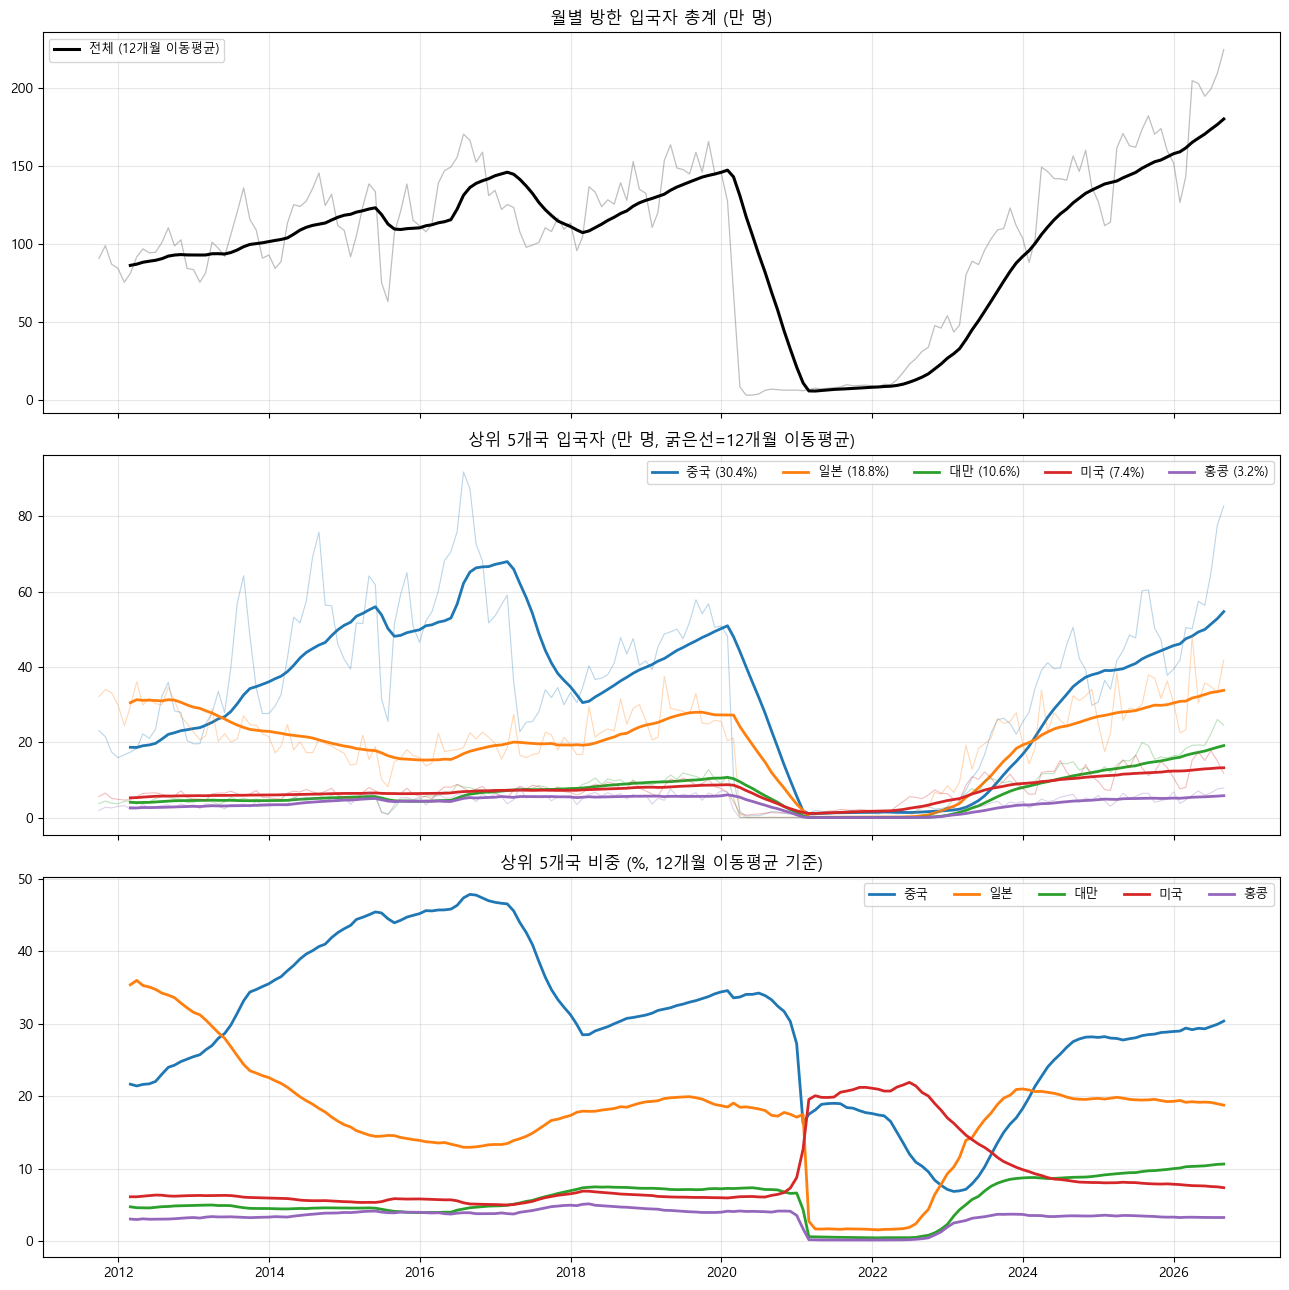

In [14]:
import matplotlib
import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager


def set_korean_font():
    prefer = {
        "Windows": ["Malgun Gothic", "NanumGothic", "Gulim"],
        "Darwin":  ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic"],
        "Linux":   ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR"],
    }
    have = {f.name for f in font_manager.fontManager.ttflist}
    for name in prefer.get(platform.system(), []) + ["Malgun Gothic", "AppleGothic"]:
        if name in have:
            matplotlib.rcParams["font.family"] = name
            return name
    print("!! 한글 폰트를 찾지 못했습니다.")
    return None


print("차트 폰트:", set_korean_font())
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 최근 12개월 누적 기준 상위 N개국 자동 선정
recent12 = wide.tail(12).sum().drop("전체", errors="ignore")
TOP = list(recent12.sort_values(ascending=False).head(TOP_N_CHART).index)
share = (recent12[TOP] / recent12.sum() * 100).round(1)
print("상위 {}개국: ".format(TOP_N_CHART)
      + ", ".join("{}({}%)".format(c, share[c]) for c in TOP))

MA = SMOOTH_MONTHS
_ma = lambda ser: ser.rolling(MA, min_periods=max(3, MA // 2)).mean()

fig, ax = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

# (1) 전체
ax[0].plot(wide.index, wide["전체"] / 1e4, color="gray", lw=0.9, alpha=0.5)
ax[0].plot(wide.index, _ma(wide["전체"]) / 1e4, color="k", lw=2.2,
           label="전체 ({}개월 이동평균)".format(MA))
ax[0].set_title("월별 방한 입국자 총계 (만 명)" if ED_CODE == "E"
                else "월별 국민 해외관광객 총계 (만 명)")
ax[0].legend(fontsize=9)
ax[0].grid(alpha=0.3)

# (2) 상위 N개국 절대 인원
colors = plt.cm.tab10.colors
for i, c in enumerate(TOP):
    col = colors[i % len(colors)]
    ax[1].plot(wide.index, wide[c] / 1e4, color=col, lw=0.8, alpha=0.30)
    ax[1].plot(wide.index, _ma(wide[c]) / 1e4, color=col, lw=2.0,
               label="{} ({}%)".format(c, share[c]))
ax[1].set_title("상위 {}개국 입국자 (만 명, 굵은선={}개월 이동평균)".format(
    TOP_N_CHART, MA))
ax[1].legend(ncol=TOP_N_CHART, fontsize=9)
ax[1].grid(alpha=0.3)

# (3) 상위 N개국 비중
tot_ma = _ma(wide["전체"])
for i, c in enumerate(TOP):
    ax[2].plot(wide.index, _ma(wide[c]) / tot_ma * 100,
               color=colors[i % len(colors)], lw=2.0, label=c)
ax[2].set_title("상위 {}개국 비중 (%, {}개월 이동평균 기준)".format(TOP_N_CHART, MA))
ax[2].legend(ncol=TOP_N_CHART, fontsize=9)
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# 최근 12개월 국적별 순위
top = wide.tail(12).sum().drop("전체", errors="ignore").sort_values(ascending=False)
tot = top.sum()

print("최근 12개월 누적 ({} ~ {})".format(
    wide.index[-12].strftime("%Y-%m"), wide.index[-1].strftime("%Y-%m")))
print("총 {:,.0f}명\n".format(tot))
print("{:<4}{:<14}{:>14}{:>9}".format("순위", "국적", "인원", "비중"))
for i, (k, v) in enumerate(top.head(15).items(), 1):
    print("{:<4}{:<14}{:>14,.0f}{:>8.1f}%".format(i, k, v, v / tot * 100))

최근 12개월 누적 (2025-09 ~ 2026-08)
총 21,605,499명

순위  국적                        인원       비중
1   중국                 6,563,497    30.4%
2   일본                 4,054,180    18.8%
3   대만                 2,294,588    10.6%
4   미국                 1,588,610     7.4%
5   홍콩                   699,104     3.2%
6   필리핀                  678,127     3.1%
7   베트남                  581,691     2.7%
8   싱가포르                 425,483     2.0%
9   인도네시아                419,735     1.9%
10  태국                   363,641     1.7%
11  말레이시아                352,328     1.6%
12  캐나다                  311,044     1.4%
13  오스트레일리아              289,800     1.3%
14  러시아(연방)              238,297     1.1%
15  인도                   224,628     1.0%


## 10. 트러블슈팅

**전 기간 실패 / `SERVICE KEY IS NOT REGISTERED`**
- 관광공사 출입국관광통계는 공공데이터포털에서 **별도 활용신청**이 필요합니다.
  금융위 API 승인과 무관합니다.
- 키는 `DATA/KEYS.py` 의 `KEYS["TOUR"]`(없으면 `KEYS["ODPD"]`)에서 읽습니다. Decoding 키를 넣으세요.
- Decoding 키를 `params=` 로 넘기는 것이 맞습니다. Encoding 키를 넣으면 이중 인코딩됩니다.

**특정 월만 반복 실패**
- `MAX_WORKERS` 를 3 이하로 낮춰보세요. 동시 요청이 많으면 서버가 끊습니다.
- 실패한 달은 `failed` 리스트에 남아 있습니다. 그 달만 다시 돌리려면
  `fetch_bulk([ym for ym, _ in failed])` 로 재시도하세요.

**'전체' 값이 실제 발표치보다 큼**
- 응답에 대륙 소계 행이 섞여 이중 계산된 경우입니다. 5번 진단 셀 결과를 보고
  `EXCLUDE_NAMES` 에 해당 국적명을 넣은 뒤 7번 셀부터 다시 실행하세요.
- 관광공사 발표 월별 방한객 수와 한두 달 대조해보면 금방 확인됩니다.

**최근 달 데이터가 없음**
- 출입국 통계는 한 달 이상 시차를 두고 공표됩니다. 기본값이 '지난달까지' 인 이유입니다.

**DB 관련**
- `config` import 오류: 노트북을 investment_strategy 폴더 아래에서 열어야 DATA 폴더를 찾습니다.
- 처음부터 다시 받고 싶으면 `MODE = "full"`. 기존 값은 덮어쓰고, 바뀐 값만 vintage에 기록됩니다.
- 소계 국적을 나중에 발견하면 `EXCLUDE_NAMES`에 넣고 다시 실행하면 코드표의 제외 표시가 갱신됩니다.

**`[6] OneDrive 경로를 찾지 못해...`** (SAVE_CSV = True 일 때)
- `OUT_DIR_OVERRIDE` 에 직접 넣으세요. 문자열 앞 `r` 을 빼면 `\U`, `\8` 등이
  이스케이프로 해석되어 깨집니다.

**엑셀에서 한글 깨짐**
- `utf-8-sig` 로 저장하므로 정상입니다. 그래도 깨지면 엑셀에서 '데이터 → 텍스트/CSV'
  로 가져오면서 인코딩을 UTF-8 로 지정하세요.